# 1 - Defining the X and y

In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import RandomizedSearchCV

df = pd.read_csv("../data/processed/interpreted_data.csv")

X = df.drop(columns="Diabete_risk")
y = df["Diabete_risk"]

# 2 - Splitting train/test

In [138]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3 - Analyze class distribution

<function matplotlib.pyplot.show(close=None, block=None)>

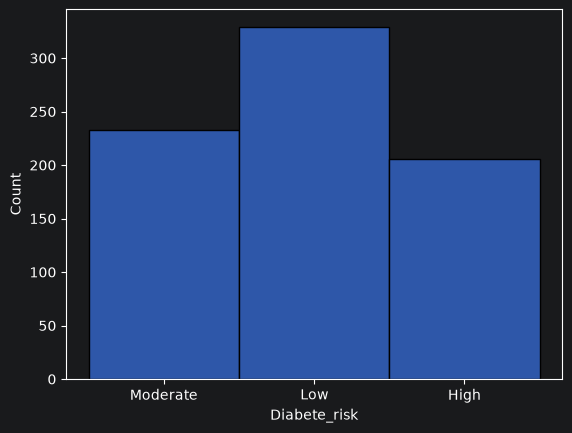

In [139]:
sns.histplot(data=df,x="Diabete_risk")
plt.show

In [140]:
print(df["Diabete_risk"].value_counts(normalize=True) * 100)

Diabete_risk
Low         42.838542
Moderate    30.338542
High        26.822917
Name: proportion, dtype: float64


# 4 - Building Preprocessing Pipeline

In [141]:
pipeline = Pipeline([
    ("impute",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num",pipeline,X.columns)
])

# 5 - Selecting classifiers

In [142]:
logistic_regression_model = Pipeline([
    ("preprocessor",preprocessor),
    ("classifier",LogisticRegression(
        solver='saga',
        max_iter=10000
    ))
])

knn_classifier_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

decision_tree_model = DecisionTreeClassifier()

random_forest_model = RandomForestClassifier()

svc = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SVC())
])

naive_bayes_model = GaussianNB()

gradient_boosting_model = GradientBoostingClassifier()

models = {
    "Logistic Regression": logistic_regression_model,
    "KNeighbors Classifier": knn_classifier_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "SVC": svc,
    "Naive Bayes": naive_bayes_model,
    "Gradient Boosting": gradient_boosting_model
}

# 6 - Training models

In [143]:
for name,model in models.items():
    model.fit(X_train,y_train)

    prediction = model.predict(X_test)
    print("===================================")
    print("===================================")
    print("Model:",name)
    print("Accuracy:", accuracy_score(y_test, prediction))

    print("\nClassification Report:")
    print(classification_report(y_test, prediction))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, prediction))
    print("\n")

Model: Logistic Regression
Accuracy: 0.9935064935064936

Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.98      0.99        41
         Low       1.00      1.00      1.00        66
    Moderate       0.98      1.00      0.99        47

    accuracy                           0.99       154
   macro avg       0.99      0.99      0.99       154
weighted avg       0.99      0.99      0.99       154


Confusion Matrix:
[[40  0  1]
 [ 0 66  0]
 [ 0  0 47]]


Model: KNeighbors Classifier
Accuracy: 0.922077922077922

Classification Report:
              precision    recall  f1-score   support

        High       0.92      0.85      0.89        41
         Low       0.91      0.97      0.94        66
    Moderate       0.93      0.91      0.92        47

    accuracy                           0.92       154
   macro avg       0.92      0.91      0.92       154
weighted avg       0.92      0.92      0.92       154


Confusion Matrix:


# 7 - Hyperparameters Optimization

In [144]:
param_grid = [
    {
        'classifier__l1_ratio': [0],
        'classifier__C': np.logspace(-3, 3, 20),
    },
    {
        'classifier__l1_ratio': [1],
        'classifier__C': np.logspace(-3, 3, 20),
    },
    {
        'classifier__l1_ratio': [0.25, 0.5, 0.75],
        'classifier__C': np.logspace(-3, 3, 20),
    }
]

search = RandomizedSearchCV(
    estimator=logistic_regression_model,
    param_distributions=param_grid,
    cv=5,
    n_iter=30,
    scoring="f1_macro",
    random_state=42,
    n_jobs=1
)

search.fit(X_train,y_train)
print("Best parameters:", search.best_params_)
print("Best CV score:", search.best_score_ * 100)

Best parameters: {'classifier__l1_ratio': 0.25, 'classifier__C': np.float64(6.158482110660261)}
Best CV score: 99.17141684436558


In [145]:
best_model = search.best_estimator_

y_pred = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Test Accuracy: 0.9805194805194806

Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.95      0.97        41
         Low       0.98      0.98      0.98        66
    Moderate       0.96      1.00      0.98        47

    accuracy                           0.98       154
   macro avg       0.98      0.98      0.98       154
weighted avg       0.98      0.98      0.98       154


Confusion Matrix:
[[39  1  1]
 [ 0 65  1]
 [ 0  0 47]]
